In [ ]:
# put this in a cell
import numpy as np
from PIL import Image, ImageOps

def make_25D_from_pgm(pgm_path, out_height_png="terrain_heightmap.png",
                      out_obj=None, res_m=0.05,
                      wall_height=3.0, base_height=0.2,
                      wall_thresh=0.7, und_amp=0.25, und_pass=3,
                      rng_seed=42):
    img = Image.open(pgm_path)
    img = ImageOps.autocontrast(img)
    arr = np.array(img).astype(np.float32)
    free = arr / max(arr.max(), 255.0)
    free_inv = 1.0 - free
    free_inv = (free_inv - free_inv.min()) / (free_inv.max() - free_inv.min() + 1e-9)

    H = base_height * (1.0 - free_inv) + wall_height * (free_inv > wall_thresh)

    rng = np.random.default_rng(rng_seed)
    noise = rng.normal(0, 1, size=H.shape)
    for _ in range(und_pass):
        noise = (np.roll(noise,1,0)+noise+np.roll(noise,-1,0))/3.0
        noise = (np.roll(noise,1,1)+noise+np.roll(noise,-1,1))/3.0
    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-9)
    und = und_amp * (noise - 0.5)
    H = H + und * (free_inv < wall_thresh)

    Hn = (H - H.min()) / (H.max() - H.min() + 1e-9)
    Image.fromarray((Hn*65535).astype(np.uint16), mode="I;16").save(out_height_png)
    print(f"[✓] Wrote heightmap: {out_height_png}")

    if out_obj:
        h, w = H.shape
        with open(out_obj, "w") as f:
            for y in range(h):
                for x in range(w):
                    f.write(f"v {x*res_m:.4f} {y*res_m:.4f} {H[y,x]:.4f}\n")
            def idx(x,y): return y*w + x + 1
            for y in range(h-1):
                for x in range(w-1):
                    v0, v1, v2, v3 = idx(x,y), idx(x+1,y), idx(x+1,y+1), idx(x,y+1)
                    f.write(f"f {v0} {v1} {v2}\n")
                    f.write(f"f {v0} {v2} {v3}\n")
        print(f"[✓] Wrote mesh OBJ: {out_obj}")
    return H


In [ ]:
H = make_25D_from_pgm("hamr_maze_big.pgm",
                      out_height_png="terrain_heightmap.png",
                      out_obj="terrain_mesh.obj",
                      res_m=0.05)


In [ ]:
# Recreate after kernel reset (stateful notebook reset).

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

cells_x = 10
cells_y = 10
res_m = 1.0

occ = np.zeros((cells_y, cells_x), dtype=np.uint8)
occ[0,:] = 1; occ[-1,:] = 1; occ[:,0] = 1; occ[:,-1] = 1

yy, xx = np.mgrid[0:cells_y, 0:cells_x]
X = xx * res_m
Y = yy * res_m
cx, cy = (cells_x-1)/2.0*res_m, (cells_y-1)/2.0*res_m
amp_m = 0.6
sigma_m = 2.5
R2 = ((X - cx)**2 + (Y - cy)**2) / (2.0 * sigma_m**2)
H = amp_m * np.exp(-R2)

mask_free = occ == 0
pts = np.stack([X[mask_free], Y[mask_free], H[mask_free]], axis=1)

csv_path = "pointcloud_10x10.csv"
pd.DataFrame(pts, columns=["x","y","z"]).to_csv(csv_path, index=False)

ply_path = "pointcloud_10x10.ply"
with open(ply_path, "w") as f:
    f.write("ply\nformat ascii 1.0\n")
    f.write(f"element vertex {pts.shape[0]}\n")
    f.write("property float x\nproperty float y\nproperty float z\n")
    f.write("end_header\n")
    for x,y,z in pts:
        f.write(f"{x:.4f} {y:.4f} {z:.4f}\n")

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=20)
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_zlabel("Z [m]")
ax.set_title("10x10 Point Cloud (edges occupied)")
plt.show()

csv_path, ply_path, pts.shape


In [ ]:
# Create a blank PGM occupancy map with occupied outer edges.
# Convention (ROS map_server style):
#   0   = occupied (black)
#   254 = free (white)
# We'll make a tiny 10x10 grid to match your earlier example (1 m per cell).
# We'll also write a matching YAML so you can load it with map_server.

import numpy as np
from PIL import Image
import yaml

w, h = 80, 80            # cells
res_m = 0.2              # meters per cell
occupied = 0
free = 254

grid = np.full((h, w), free, dtype=np.uint8)
grid[0, :] = occupied
grid[-1, :] = occupied
grid[:, 0] = occupied
grid[:, -1] = occupied

pgm_path = "blank_10x10.pgm"
img = Image.fromarray(grid, mode="L")
img.save(pgm_path, format="PPM")  # PIL writes PGM/PPM via "PPM" for L-mode

yaml_dict = {
    "image": "blank_10x10.pgm",
    "resolution": float(res_m),
    "origin": [-7.0, -7.0, 0.0],     # bottom-left at (0,0); adjust as needed
    "negate": 0,
    "occupied_thresh": 0.65,
    "free_thresh": 0.196
}
yaml_path = "blank_10x10.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(yaml_dict, f, default_flow_style=False)

pgm_path, yaml_path, grid.shape, (grid.min(), grid.max())


In [ ]:
# Path planning on a grayscale heightmap (deterministic costs, with slope limits)
# - Loads the provided image as elevation
# - Builds an 8-connected grid with costs
# - Blocks cells with slope > max_slope_deg
# - Runs A* to find a least-cost path
# - Plots the result over the map
#
# You can tweak: max_slope_deg, height_scale_m_per_intensity, weights

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from heapq import heappush, heappop

# --- Load the grayscale "heightmap" ---
img_path = "/home/kartik/hamr_ws/src/hamr_holonomic_robot/hamr_bringup/terrain_assets/heightmaps/off_road_maps/terrain1_1025_10.png"
img = Image.open(img_path).convert("L")  # grayscale
Z = np.asarray(img, dtype=np.float32) / 255.0  # normalize to [0,1]
h, w = Z.shape

# --- Parameters you might want to adjust ---
cell_size_m = 1.0  # meters per pixel (assumed)
height_scale_m_per_intensity = 30.0  # how many meters of elevation per 0->1 intensity change
max_slope_deg = 20.0  # robot's max safe slope (degrees)

# cost weights
w_up = 4.0         # uphill penalty per meter climbed
w_down = 1.0       # downhill penalty per meter descended (risk, braking)
w_slope = 2.0      # additional slope penalty (smoothness/traction)
w_rough = 0.5      # roughness penalty (local variance proxy)

# --- Compute derived fields ---
# Elevation in meters
H = Z * height_scale_m_per_intensity

# Gradient-based slope (rise/run). gradient returns dH/dy and dH/dx in meters per pixel.
dHy, dHx = np.gradient(H, cell_size_m)
slope_rad = np.arctan(np.sqrt(dHx**2 + dHy**2))  # arctan(|grad|)
slope_deg = np.degrees(slope_rad)

# Simple roughness proxy: local standard deviation in a 5x5 window
from scipy.ndimage import uniform_filter
mean_H = uniform_filter(H, size=5)
mean_H2 = uniform_filter(H**2, size=5)
rough = np.sqrt(np.maximum(mean_H2 - mean_H**2, 0.0))

# Traversability mask
traversable = slope_deg <= max_slope_deg

# --- A* on 8-connected grid ---
# Moves: (dy, dx) with cost multiplier for diagonal
moves = [(-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0),
         (-1, -1, np.sqrt(2)), (-1, 1, np.sqrt(2)), (1, -1, np.sqrt(2)), (1, 1, np.sqrt(2))]

def in_bounds(y, x):
    return 0 <= y < h and 0 <= x < w

def step_cost(y0, x0, y1, x1, base_mult):
    # Base distance cost
    base = base_mult * cell_size_m

    # Elevation change (meters)
    dz = H[y1, x1] - H[y0, x0]
    uphill = max(0.0, dz)
    downhill = max(0.0, -dz)

    # Slope and roughness at the target cell
    s_deg = slope_deg[y1, x1]
    r = rough[y1, x1]

    # Aggregate cost
    c = base + w_up*uphill + w_down*downhill + w_slope*(s_deg/max_slope_deg) + w_rough*r
    # Block very steep transitions explicitly
    if not traversable[y1, x1]:
        c = np.inf
    return c

def heuristic(y, x, gy, gx):
    # Euclidean distance in meters (admissible)
    return np.hypot(gy - y, gx - x) * cell_size_m

def astar(start, goal):
    sy, sx = start
    gy, gx = goal
    if not (in_bounds(sy, sx) and in_bounds(gy, gx)):
        raise ValueError("Start or goal is out of bounds")
    if not (traversable[sy, sx] and traversable[gy, gx]):
        raise ValueError("Start or goal is not traversable at given slope limit")

    gscore = np.full((h, w), np.inf, dtype=np.float64)
    fscore = np.full((h, w), np.inf, dtype=np.float64)
    parent_y = np.full((h, w), -1, dtype=np.int32)
    parent_x = np.full((h, w), -1, dtype=np.int32)

    gscore[sy, sx] = 0.0
    fscore[sy, sx] = heuristic(sy, sx, gy, gx)

    pq = []
    heappush(pq, (fscore[sy, sx], (sy, sx)))

    visited = np.zeros((h, w), dtype=bool)

    while pq:
        _, (y, x) = heappop(pq)
        if visited[y, x]:
            continue
        visited[y, x] = True

        if (y, x) == (gy, gx):
            # Reconstruct path
            path = [(y, x)]
            while not (y == sy and x == sx):
                py, px = parent_y[y, x], parent_x[y, x]
                y, x = py, px
                path.append((y, x))
            path.reverse()
            return path, gscore[gy, gx]

        for dy, dx, mult in moves:
            ny, nx = y + dy, x + dx
            if not in_bounds(ny, nx) or visited[ny, nx]:
                continue
            c = step_cost(y, x, ny, nx, mult)
            if not np.isfinite(c):
                continue
            tentative = gscore[y, x] + c
            if tentative < gscore[ny, nx]:
                gscore[ny, nx] = tentative
                fscore[ny, nx] = tentative + heuristic(ny, nx, gy, gx)
                parent_y[ny, nx] = y
                parent_x[ny, nx] = x
                heappush(pq, (fscore[ny, nx], (ny, nx)))

    return None, np.inf

# Choose example start/goal (you can modify these indices)
start = (20, 20)
goal  = (h-20, w-20)

path, total_cost = astar(start, goal)

# --- Plot result ---
plt.figure(figsize=(8, 8))
plt.imshow(Z)  # default colormap
plt.title(f"Planned path (A*). Total cost: {total_cost:.1f}\nwhite=high elevation, dark=low")
plt.axis('off')

if path is not None:
    ys, xs = zip(*path)
    plt.plot(xs, ys, linewidth=2)  # default color/linewidth
    # Show start/goal markers
    plt.scatter([start[1], goal[1]], [start[0], goal[0]], s=40)
else:
    plt.text(w*0.5, h*0.5, "No path found", ha='center', va='center')

plt.show()


In [ ]:
# Re-run with downsampling to keep it snappy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from heapq import heappush, heappop

def plan_on_image(path, scale_to=256, start=None, goal=None,
                  cell_size_m=1.0, height_scale_m_per_intensity=30.0,
                  max_slope_deg=20.0, w_up=4.0, w_down=1.0, w_slope=2.0, w_rough=0.5):
    img = Image.open(path).convert("L")
    img_small = img.resize((scale_to, scale_to), Image.BILINEAR)
    Z = np.asarray(img_small, dtype=np.float32) / 255.0
    h, w = Z.shape

    H = Z * height_scale_m_per_intensity
    dHy, dHx = np.gradient(H, cell_size_m)
    slope_rad = np.arctan(np.sqrt(dHx**2 + dHy**2))
    slope_deg = np.degrees(slope_rad)

    from scipy.ndimage import uniform_filter
    mean_H = uniform_filter(H, size=5)
    mean_H2 = uniform_filter(H**2, size=5)
    rough = np.sqrt(np.maximum(mean_H2 - mean_H**2, 0.0))

    traversable = slope_deg <= max_slope_deg

    moves = [(-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0),
             (-1, -1, np.sqrt(2)), (-1, 1, np.sqrt(2)), (1, -1, np.sqrt(2)), (1, 1, np.sqrt(2))]

    def in_bounds(y, x):
        return 0 <= y < h and 0 <= x < w

    def step_cost(y0, x0, y1, x1, base_mult):
        base = base_mult * cell_size_m
        dz = H[y1, x1] - H[y0, x0]
        uphill = max(0.0, dz)
        downhill = max(0.0, -dz)
        s_deg = slope_deg[y1, x1]
        r = rough[y1, x1]
        if not traversable[y1, x1]:
            return np.inf
        return base + w_up*uphill + w_down*downhill + w_slope*(s_deg/max_slope_deg) + w_rough*r

    def heuristic(y, x, gy, gx):
        return np.hypot(gy - y, gx - x) * cell_size_m

    if start is None:
        start = (5, 5)
    if goal is None:
        goal = (h-6, w-6)

    sy, sx = start
    gy, gx = goal
    if not (in_bounds(sy, sx) and in_bounds(gy, gx)):
        raise ValueError("Start or goal is out of bounds")
    if not (traversable[sy, sx] and traversable[gy, gx]):
        raise ValueError("Start or goal is not traversable at given slope limit")

    gscore = np.full((h, w), np.inf, dtype=np.float64)
    fscore = np.full((h, w), np.inf, dtype=np.float64)
    parent_y = np.full((h, w), -1, dtype=np.int32)
    parent_x = np.full((h, w), -1, dtype=np.int32)

    gscore[sy, sx] = 0.0
    fscore[sy, sx] = heuristic(sy, sx, gy, gx)
    pq, visited = [], np.zeros((h, w), dtype=bool)
    heappush(pq, (fscore[sy, sx], (sy, sx)))

    while pq:
        _, (y, x) = heappop(pq)
        if visited[y, x]:
            continue
        visited[y, x] = True

        if (y, x) == (gy, gx):
            path = [(y, x)]
            while not (y == sy and x == sx):
                y, x = parent_y[y, x], parent_x[y, x]
                path.append((y, x))
            path.reverse()
            return Z, path, gscore[gy, gx], traversable

        for dy, dx, mult in moves:
            ny, nx = y + dy, x + dx
            if not in_bounds(ny, nx) or visited[ny, nx]:
                continue
            c = step_cost(y, x, ny, nx, mult)
            if not np.isfinite(c):
                continue
            tentative = gscore[y, x] + c
            if tentative < gscore[ny, nx]:
                gscore[ny, nx] = tentative
                fscore[ny, nx] = tentative + heuristic(ny, nx, gy, gx)
                parent_y[ny, nx] = y
                parent_x[ny, nx] = x
                heappush(pq, (fscore[ny, nx], (ny, nx)))

    return Z, None, np.inf, traversable

Z_small, path, total_cost, traversable = plan_on_image("/home/kartik/hamr_ws/src/hamr_holonomic_robot/hamr_bringup/terrain_assets/heightmaps/off_road_maps/terrain1_1025_10.png", scale_to=256)

plt.figure(figsize=(7,7))
plt.imshow(Z_small)
plt.title(f"A* path on heightmap (downsampled)\nTotal cost: {total_cost:.1f}")
plt.axis('off')
if path is not None:
    ys, xs = zip(*path)
    plt.plot(xs, ys, linewidth=2)
    plt.scatter([path[0][1], path[-1][1]], [path[0][0], path[-1][0]], s=40)
else:
    plt.text(Z_small.shape[1]*0.5, Z_small.shape[0]*0.5, "No path found", ha='center', va='center')
plt.show()


In [ ]:
%matplotlib notebook

/tmp/ipykernel_51332/3111010193.py:49: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  pts = plt.ginput(2, timeout=30)  # returns list of (x,y)


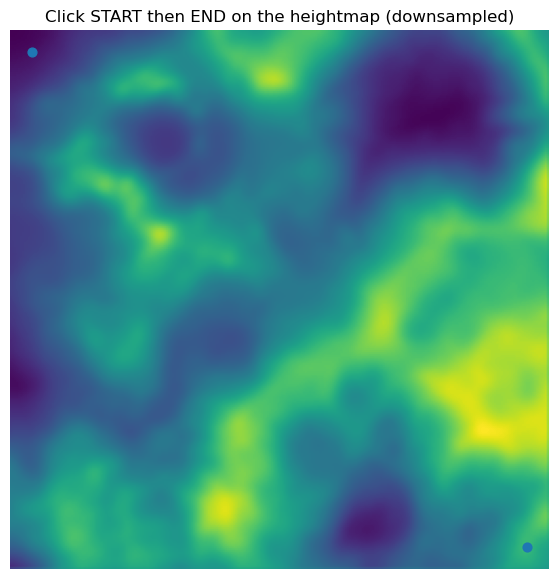

Grid size: 256 x 256
Selected start_rc (row,col): (10, 10)
Selected goal_rc  (row,col): (245, 245)


In [1]:
# === Cell 1: Build grid from grayscale map and pick start/end ===
# Tips:
# - In Jupyter, interactive clicks usually work with "%matplotlib notebook" (or ipympl).
#   If clicks don't register, run:  %matplotlib notebook   in a cell first.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import uniform_filter

# -------------------- user knobs (cell 1) --------------------
image_path = "terrain1_1025_10.png"   # change if needed
scale_to   = 256                      # downsample side-length (speeds everything up)
cell_size_m = 1.0                     # meters per pixel (assumed)
height_scale_m_per_intensity = 30.0   # meters per 0→1 intensity change
rough_win = 5                         # window for roughness (std-dev proxy)
# -------------------------------------------------------------

# Load greyscale heightmap and normalize to [0,1]
_img = Image.open(image_path).convert("L")
_img_small = _img.resize((scale_to, scale_to), Image.Resampling.BILINEAR)
Z = np.asarray(_img_small, dtype=np.float32) / 255.0   # normalized grey
h, w = Z.shape

# Elevation (meters)
H = Z * height_scale_m_per_intensity

# Slope (deg) from gradient magnitude
dHy, dHx = np.gradient(H, cell_size_m)
slope_rad = np.arctan(np.sqrt(dHx**2 + dHy**2))
slope_deg = np.degrees(slope_rad)

# Roughness (local std deviation of elevation)
mean_H = uniform_filter(H, size=rough_win)
mean_H2 = uniform_filter(H**2, size=rough_win)
rough = np.sqrt(np.maximum(mean_H2 - mean_H**2, 0.0))

# Visualize the heightmap
fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(Z)
ax.set_title("Click START then END on the heightmap (downsampled)")
ax.axis("off")

# Interactive picking (fallback to manual if needed)
start_rc = None
goal_rc  = None
try:
    # try interactive clicks
    pts = plt.ginput(2, timeout=30)  # returns list of (x,y)
    if len(pts) == 2:
        # convert from (x,y) to (row, col), clip to image bounds
        (x0, y0), (x1, y1) = pts
        start_rc = (int(round(y0)), int(round(x0)))
        goal_rc  = (int(round(y1)), int(round(x1)))
except Exception as _:
    pass

# If interactive pick failed, set to reasonable defaults (top-left to bottom-right-ish)
if start_rc is None or goal_rc is None:
    start_rc = (10, 10)
    goal_rc  = (h-11, w-11)

# Draw picked points
ax.scatter([start_rc[1], goal_rc[1]], [start_rc[0], goal_rc[0]], s=40)
plt.show()

print(f"Grid size: {h} x {w}")
print(f"Selected start_rc (row,col): {start_rc}")
print(f"Selected goal_rc  (row,col): {goal_rc}")

# Keep arrays in notebook memory for the next cell:
_grid_artifacts = dict(
    Z=Z, H=H, slope_deg=slope_deg, rough=rough,
    cell_size_m=cell_size_m, height_scale_m_per_intensity=height_scale_m_per_intensity,
    start_rc=start_rc, goal_rc=goal_rc
)


In [ ]:
# === Cell 2: Parameters + A* planner and visualization ===
import numpy as np
import matplotlib.pyplot as plt
from heapq import heappush, heappop

# -------------------- user knobs (cell 2) --------------------
# Robot capability / terrain costs
max_slope_deg = 20.0   # max allowable slope (deg) — set to your robot limit
w_up    = 4.0          # uphill cost per meter climbed
w_down  = 1.0          # downhill cost per meter descended
w_slope = 2.0          # extra penalty scaled by (slope / max_slope_deg)
w_rough = 0.5          # roughness penalty weight
# -------------------------------------------------------------

# Unpack arrays saved from Cell 1
Z          = _grid_artifacts["Z"]
H          = _grid_artifacts["H"]
slope_deg  = _grid_artifacts["slope_deg"]
rough      = _grid_artifacts["rough"]
cell_size_m = _grid_artifacts["cell_size_m"]
start_rc   = _grid_artifacts["start_rc"]
goal_rc    = _grid_artifacts["goal_rc"]

h, w = Z.shape
traversable = slope_deg <= max_slope_deg

# 8-connected grid moves: (dy, dx, length-mult)
_moves = [(-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0),
          (-1, -1, np.sqrt(2)), (-1, 1, np.sqrt(2)), (1, -1, np.sqrt(2)), (1, 1, np.sqrt(2))]

def _in_bounds(y, x):
    return 0 <= y < h and 0 <= x < w

def step_cost(y0, x0, y1, x1, base_mult):
    # base travel distance
    base = base_mult * cell_size_m
    # elevation change
    dz = H[y1, x1] - H[y0, x0]
    uphill   = max(0.0,  dz)
    downhill = max(0.0, -dz)
    # terrain features at target cell
    s_deg = slope_deg[y1, x1]
    r     = rough[y1, x1]
    if not traversable[y1, x1]:
        return np.inf
    return base + w_up*uphill + w_down*downhill + w_slope*(s_deg/max_slope_deg) + w_rough*r

def heuristic(y, x, gy, gx):
    # Euclidean distance (meters) — admissible
    return np.hypot(gy - y, gx - x) * cell_size_m

def astar(start, goal):
    sy, sx = start
    gy, gx = goal
    if not (_in_bounds(sy, sx) and _in_bounds(gy, gx)):
        raise ValueError("Start or goal out of bounds")
    if not (traversable[sy, sx] and traversable[gy, gx]):
        raise ValueError("Start or goal is not traversable at this slope limit")

    g = np.full((h, w), np.inf, dtype=np.float64)
    f = np.full((h, w), np.inf, dtype=np.float64)
    parent_y = np.full((h, w), -1, dtype=np.int32)
    parent_x = np.full((h, w), -1, dtype=np.int32)

    g[sy, sx] = 0.0
    f[sy, sx] = heuristic(sy, sx, gy, gx)

    pq = []
    heappush(pq, (f[sy, sx], (sy, sx)))
    visited = np.zeros((h, w), dtype=bool)

    while pq:
        _, (y, x) = heappop(pq)
        if visited[y, x]:
            continue
        visited[y, x] = True

        if (y, x) == (gy, gx):
            # reconstruct path
            path = [(y, x)]
            while not (y == sy and x == sx):
                y, x = parent_y[y, x], parent_x[y, x]
                path.append((y, x))
            path.reverse()
            return path, g[gy, gx]

        for dy, dx, mult in _moves:
            ny, nx = y + dy, x + dx
            if not _in_bounds(ny, nx) or visited[ny, nx]:
                continue
            c = step_cost(y, x, ny, nx, mult)
            if not np.isfinite(c):
                continue
            tentative = g[y, x] + c
            if tentative < g[ny, nx]:
                g[ny, nx] = tentative
                f[ny, nx] = tentative + heuristic(ny, nx, gy, gx)
                parent_y[ny, nx] = y
                parent_x[ny, nx] = x
                heappush(pq, (f[ny, nx], (ny, nx)))

    return None, np.inf

# Run planner
try:
    path, total_cost = astar(start_rc, goal_rc)
except ValueError as e:
    print("Planner error:", e)
    path, total_cost = None, np.inf

# Visualize
plt.figure(figsize=(7,7))
plt.imshow(Z)
plt.title(f"A* path  |  start={start_rc}, goal={goal_rc}  |  cost={total_cost:.1f}")
plt.axis("off")
if path:
    ys, xs = zip(*path)
    plt.plot(xs, ys, linewidth=2)           # default color
    plt.scatter([start_rc[1], goal_rc[1]], [start_rc[0], goal_rc[0]], s=40)
else:
    plt.text(w*0.5, h*0.5, "No path found", ha='center', va='center')
plt.show()
